# Option B Exploration

This notebook contains the exploration component for Option B, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Edge/lane detection using your own images:** Apply edge detection to your own photos. Where does it go wrong? Why might that be the case? Are there other edge detection algorithms that work better?
* **Enhancing the edge detection algorithm** Can you improve the edge detection algorithm somewhere?

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: OpenCV Documentation — Canny Edge Detection https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html This tutorial explains how OpenCV implements Canny edge detection and provides detailed visualizations of each pipeline step. It helped me interpret and compare my edge detection outputs across the three environments by grounding my observations in how each stage of the algorithm contributes to the final result.

* Source 2: Canny Edge Detector — University of Edinburgh HIPR2 Reference https://homepages.inf.ed.ac.uk/rbf/HIPR2/canny.htm This reference helped me interpret how varying σ affected edge detection across my three environments, particularly its explanation of the tradeoff between noise reduction and detail preservation as the Gaussian width increases.

* Source 3: Image Processing Using Convolution Kernels in Python (Medium, Akash Singh) https://medium.com/@akashsingh9303/image-processing-using-convolution-kernels-in-python-a-practical-guide-2da3252b033a This tutorial introduced the basic 3×3 Laplacian kernel [[0,1,0],[1,-4,1],[0,1,0]] alongside other common convolution kernels like Sobel and Prewitt. It provided the starting kernel values and introductory logic for how these filters are applied to grayscale images in Python.

* Source 4: Spatial Filters — Laplacian/Laplacian of Gaussian (University of Edinburgh HIPR2) https://homepages.inf.ed.ac.uk/rbf/HIPR2/log.htm This reference provided the mathematical foundation for the Laplacian operator, explaining how it computes the second spatial derivative to produce positive and negative responses around edges, with a zero crossing at the edge itself. It also detailed why the Laplacian is sensitive to noise, why output values can exceed the input range (requiring floating point representation and absolute value handling), and why Gaussian pre-smoothing is commonly applied — all of which directly informed how I implemented and thresholded the Laplacian in my pipeline.

* Source 5: Saini, S., Kasliwal, B., & Bhatia, S. Comparative Study of Image Edge Detection Algorithms. https://arxiv.org/pdf/1311.4963 This paper compares Canny against Laplacian-based edge detection, explaining that Canny produces thin continuous edges while Laplacian methods tend to give spotty, thicker edges. It directly supports the tradeoffs I observed between the two methods in my comparison.


## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [18]:
def conv(image, kernel):
    Hi, Wi = image.shape
    Hk, Wk = kernel.shape
    out = np.zeros((Hi, Wi))

    pad_width0 = Hk // 2
    pad_width1 = Wk // 2
    pad_width = ((pad_width0,pad_width0),(pad_width1,pad_width1))
    padded = np.pad(image, pad_width, mode='edge')

    kernel = np.flip(kernel)

    for i in range(Hi):
        for j in range(Wi):
            out[i,j] = np.sum(kernel * padded[i:i+Hk, j:j+Wk])

    return out

In [19]:
def gaussian_kernel(size, sigma):
    kernel = np.zeros((size, size))

    for i in range(size):
        for j in range(size):
            kernel[i,j] = 1/(2*np.pi*sigma**2) * np.exp(
                -((i-(size-1)/2)**2 + (j-(size-1)/2)**2)/(2*sigma**2)
            )
    return kernel

In [20]:
def partial_x(img):
    return conv(img.astype(float), np.array([[1, 0, -1]]) / 2)

def partial_y(img):
    return conv(img.astype(float), np.array([[1], [0], [-1]]) / 2)

In [21]:
def gradient(img):
    Ix = partial_x(img)
    Iy = partial_y(img)

    G = np.sqrt(Ix**2 + Iy**2)
    theta = np.arctan2(Iy, Ix) * 180 / np.pi
    theta = (theta + 360) % 360

    return G, theta

In [22]:
def non_maximum_suppression(G, theta):
    H, W = G.shape
    out = np.zeros((H, W))

    theta = np.floor((theta + 22.5) / 45) * 45
    theta = (theta % 360).astype(np.int32)

    for i in range(1, H-1):
        for j in range(1, W-1):
            angle = theta[i, j] % 180

            if angle == 0:
                if G[i,j] >= G[i,j-1] and G[i,j] >= G[i,j+1]:
                    out[i,j] = G[i,j]

            elif angle == 45:
                if G[i,j] >= G[i-1,j+1] and G[i,j] >= G[i+1,j-1]:
                    out[i,j] = G[i,j]

            elif angle == 90:
                if G[i,j] >= G[i-1,j] and G[i,j] >= G[i+1,j]:
                    out[i,j] = G[i,j]

            elif angle == 135:
                if G[i,j] >= G[i-1,j-1] and G[i,j] >= G[i+1,j+1]:
                    out[i,j] = G[i,j]

    return out

In [23]:
def double_thresholding(img, high, low):
    strong = img > high
    weak = (img <= high) & (img > low)
    return strong, weak

In [24]:
def get_neighbors(y, x, H, W):
    neighbors = []
    for i in (y-1, y, y+1):
        for j in (x-1, x, x+1):
            if 0 <= i < H and 0 <= j < W:
                if (i, j) != (y, x):
                    neighbors.append((i, j))
    return neighbors

In [25]:
def link_edges(strong_edges, weak_edges):
    H, W = strong_edges.shape
    edges = np.copy(strong_edges)
    weak_edges = np.copy(weak_edges)

    indices = np.stack(np.nonzero(strong_edges)).T

    for (y, x) in indices:
        queue = [(y, x)]
        while queue:
            ycurr, xcurr = queue.pop(0)
            for (yn, xn) in get_neighbors(ycurr, xcurr, H, W):
                if weak_edges[yn, xn]:
                    edges[yn, xn] = True
                    weak_edges[yn, xn] = False
                    queue.append((yn, xn))

    return edges

In [26]:
from google.colab import files
files.upload()

{}

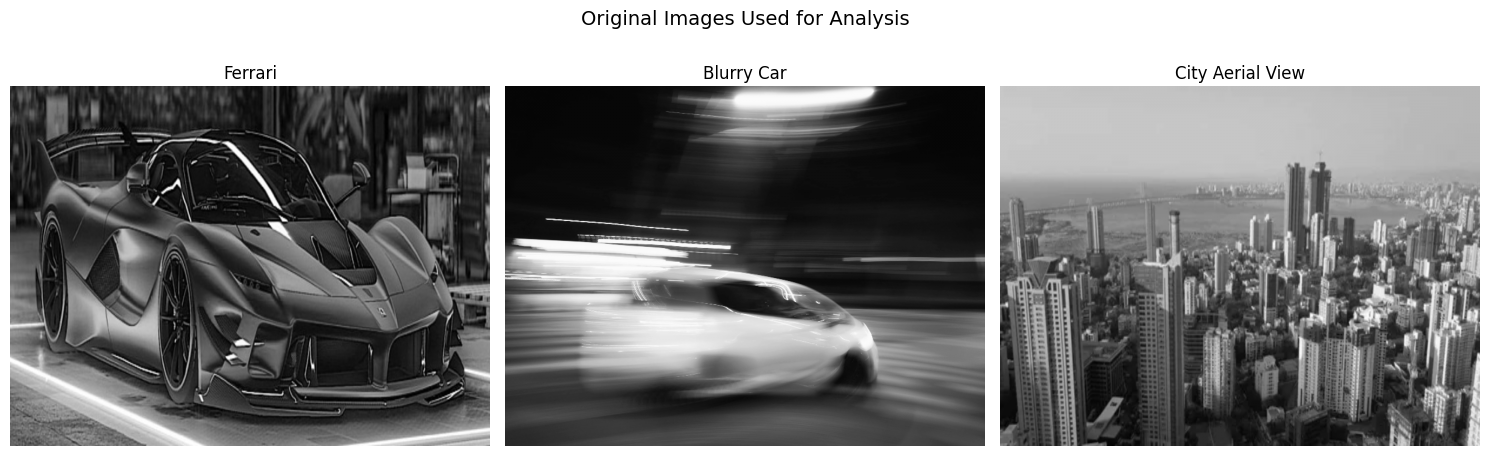

In [27]:
#loading the three original images in grayscale
ferrari = cv2.imread('ferrari image.jpg', cv2.IMREAD_GRAYSCALE)
blurrycar = cv2.imread('blurrycar image.jpg', cv2.IMREAD_GRAYSCALE)
city = cv2.imread('city aerial image.jpg', cv2.IMREAD_GRAYSCALE)

# resizing to a smaller size so that edge detection runs faster
ferrari = cv2.resize(ferrari, (800, 600))
blurrycar = cv2.resize(blurrycar, (800, 600))
city = cv2.resize(city, (800, 600))

images = [ferrari, blurrycar, city]
names = ['Ferrari', 'Blurry Car', 'City Aerial View']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for col, (img, name) in enumerate(zip(images, names)):
    axes[col].imshow(img, cmap='gray')
    axes[col].set_title(f'{name}')
    axes[col].axis('off')

plt.suptitle('Original Images Used for Analysis', fontsize=14)
plt.tight_layout()
plt.show()

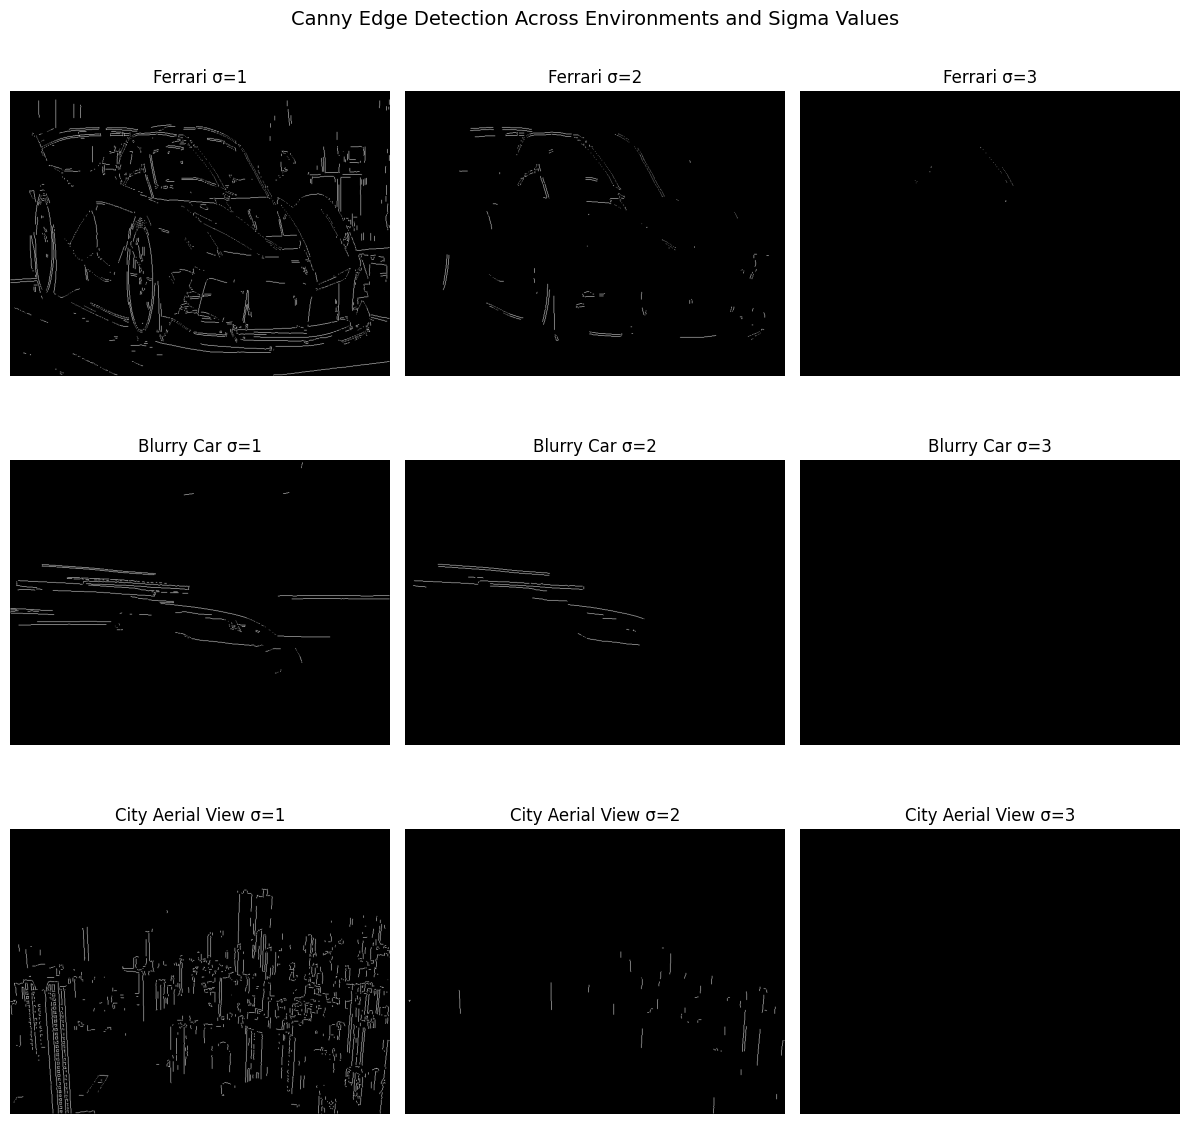

In [28]:
#analysing the effect of varying the sigma value on the canny edge detection algorithm
sigmas = [1, 2, 3]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, (img, name) in enumerate(zip(images, names)):
    for col, sigma in enumerate(sigmas):
        kernel = gaussian_kernel(5, sigma)
        smoothed = conv(img.astype(float), kernel)
        G, theta = gradient(smoothed)
        nms = non_maximum_suppression(G, theta)
        strong, weak = double_thresholding(nms, high=20, low=15)
        edges = link_edges(strong, weak)

        axes[row, col].imshow(edges, cmap='gray')
        axes[row, col].set_title(f'{name} σ={sigma}')
        axes[row, col].axis('off')

plt.suptitle('Canny Edge Detection Across Environments and Sigma Values',fontsize=14)
plt.tight_layout()
plt.show()

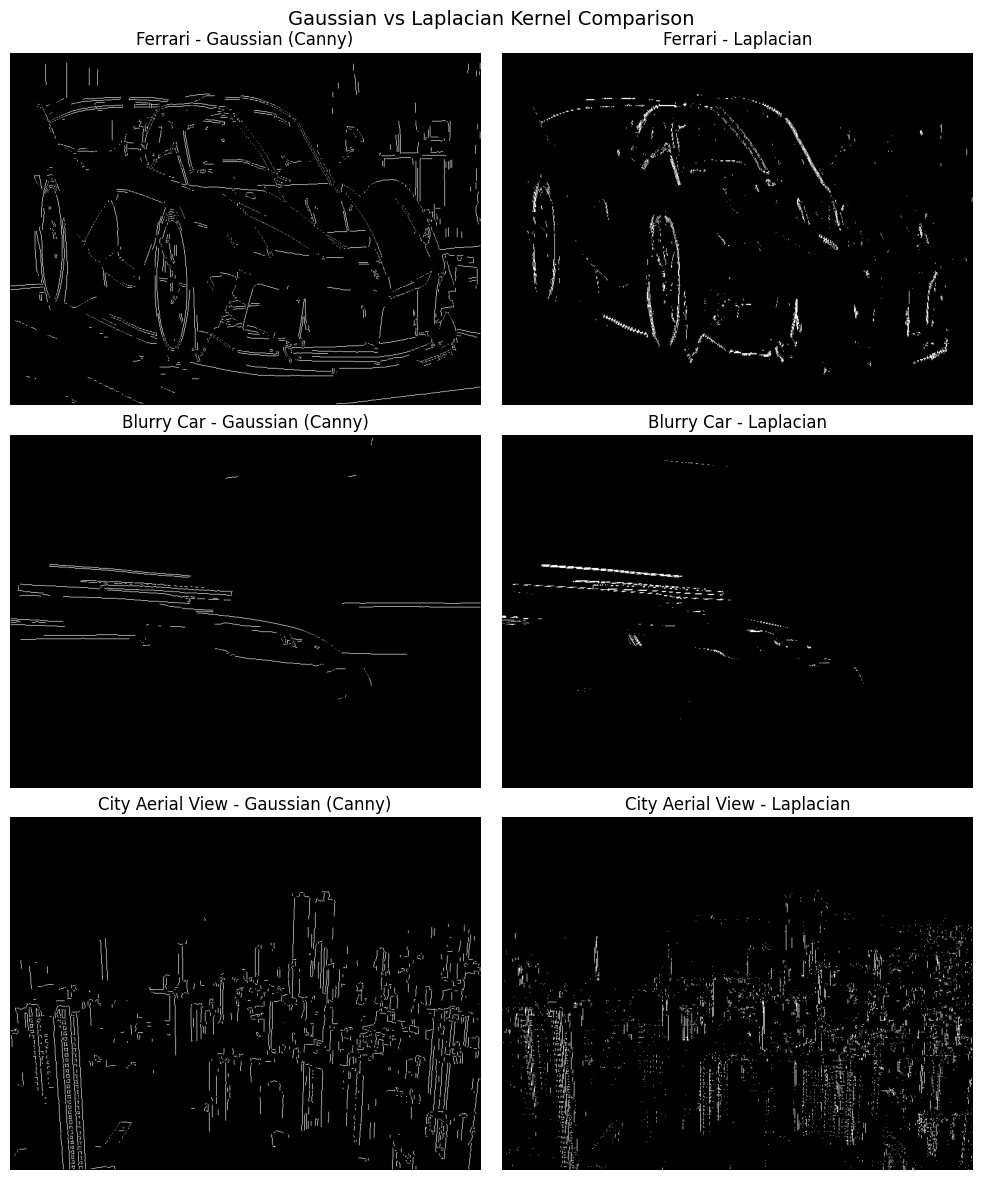

In [29]:
#comparing the canny and laplacian methods of edge detection
laplacian_kernel = np.array([[0,  1, 0],
                              [1, -4, 1],
                              [0,  1, 0]])

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for row, (img, name) in enumerate(zip(images, names)):
    kernel = gaussian_kernel(5, 1)
    smoothed = conv(img.astype(float), kernel)
    G, theta = gradient(smoothed)
    nms = non_maximum_suppression(G, theta)
    strong, weak = double_thresholding(nms, high=20, low=15)
    canny_edges = link_edges(strong, weak)

    laplacian_edges = np.abs(conv(img.astype(float), laplacian_kernel))
    laplacian_edges = laplacian_edges > (0.2 * laplacian_edges.max())

    axes[row, 0].imshow(canny_edges, cmap='gray')
    axes[row, 0].set_title(f'{name} - Gaussian (Canny)')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(laplacian_edges, cmap='gray')
    axes[row, 1].set_title(f'{name} - Laplacian')
    axes[row, 1].axis('off')

plt.suptitle('Gaussian vs Laplacian Kernel Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

In this exploration, I applied Canny edge detection to three environments: a sharp Ferrari, a motion-blurred car, and a detailed city aerial view. For each image, I varied the Gaussian sigma (σ = 1, 2, 3) to study its effect on edge detection.
As σ increases, stronger smoothing reduces gradient magnitudes, which directly impacts Canny's double-thresholding stage (high=20, low=15). Pixels with gradients below the low threshold are discarded entirely, which is why higher σ produces emptier edge maps.
At σ=1, the Ferrari image retained rich detail as its sharp boundaries produced strong gradients above the threshold. The blurry car had already lost most structure since motion blur pre-weakened its gradients, leaving only light streaks above the high threshold. The city aerial view produced a dense, detailed edge map, capturing most building silhouettes due to strong vertical contrast.
At σ=2, the Ferrari retained only its dominant contours since its baseline gradients were strong enough to partially survive smoothing. The blurry car lost nearly all remaining edges as its already-weak gradients fell below the low threshold entirely, breaking the hysteresis chain. The city’s finer details fell below the low threshold after smoothing. The remaining edges corresponded mainly to sharp contrast boundaries between sunlit and shadowed sides of buildings. By σ=3, nearly all detail was lost across every image.
This reveals a key limitation: the fixed thresholds don't scale with σ. Gradients shrink as smoothing increases, so thresholds that work at σ=1 become too aggressive by σ=2. Adaptive thresholding based on local gradient statistics would significantly improve robustness of the Canny edge detection across diverse environments.
As an additional comparison, a Laplacian filter was tested against the Canny pipeline across the three environments. The results showed that each method excelled in different contexts. Canny produced cleaner, more continuous edges on the Ferrari, capturing the car's structural contours and body shape more accurately, while Laplacian produced fragmented and patchy edges on the same image. However, on the city aerial view, Laplacian captured more of the building outlines and overall shape of the skyline, whereas Canny's results were sparser in comparison. This suggests that this Canny's smoothing, non-maximum suppression steps and hysteresis thresholding are better suited for preserving connected structures, while the Laplacian's sensitivity to second-order intensity changes performs better on scenes dominated by small, high-contrast details like dense cities.
